# Bitcoin EMA, VOL, RSI, Regime Strategy

- This is one of the simplest trading strategies
- Direction 
    - EMA + VEGAS 
- Singals
    - RIS + Vol Spike

# Set up

Set up Trading Strategy data client.


In [1]:
from tradeexecutor.utils.notebook import setup_charting_and_output
from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()

# Set up drawing charts in interactive vector output mode.
# This is slower. See the alternative commented option below.
# setup_charting_and_output(OutputMode.interactive)

# Set up rendering static PNG images.
# This is much faster but disables zoom on any chart.
setup_charting_and_output(OutputMode.static, image_format="png", width=1500, height=1000)


Started Trading Strategy in Jupyter notebook environment, configuration is stored in /home/vscode/.tradingstrategy


# Parameters

- Strategy parameters define the fixed and grid searched parameters

In [2]:
from tradingstrategy.chain import ChainId
import datetime

from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradingstrategy.timebucket import TimeBucket
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.parameters import StrategyParameters


class Parameters:
    """Parameteres for this strategy.

    - Collect parameters used for this strategy here

    - Both live trading and backtesting parameters
    """

    id = "bitcoin-EMA-VOL-RSI-REGIME" # Used in cache paths

    cycle_duration = CycleDuration.cycle_15m
    candle_time_bucket = TimeBucket.m15
    allocation = 0.98


    atr_length = 40  # 40 bars
    fract = 1.0  # Fraction between last hourly close and breakout level

    adx_length = 14  # 14 days
    adx_filter_threshold = 25
    

    trailing_stop_loss_pct = 0.98  
    trailing_stop_loss_activation_level = 1.05
    stop_loss_pct = 0.98 
    take_profit_pct = 1.10

    long_leverage = 0.0  # Currently only spot supported for long
    short_leverage = 1.0  # Leverage x for short positions
    

    #
    # Live trading only
    #
    # chain_id = ChainId.ethereum
    # routing = TradeRouting.default  # Pick default routes for trade execution
    # required_history_period = datetime.timedelta(hours=200)

    #
    # Backtesting only
    #
    backtest_start = datetime.datetime(2021, 1, 1)
    backtest_end = datetime.datetime(2025, 3, 1)
    backtest_trading_fee = 0.0005  # Override the default Binance data trading fee and assume we can trade 5 BPS fee on WMATIC-USDC on Polygon on Uniswap v3
    initial_cash = 10_000


parameters = StrategyParameters.from_class(Parameters)  # Convert to AttributedDict to easier typing with dot notation



# Trading pairs and market data

- Set up our trading pairs
- Load historical market data for backtesting
- We use Binance CEX data so we have longer history to backtest
- If you would like to use DEX data, uncomment the second cell below. Note that your backtest will have to start later since DEX data is smaller.
Also profitability will be affected due to higher fees in this case. 

In [3]:
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data
from tradingstrategy.client import Client
from tradeexecutor.strategy.execution_context import ExecutionContext, notebook_execution_context
from tradeexecutor.utils.binance import create_binance_universe
from tradeexecutor.strategy.universe_model import UniverseOptions

# List of trading pairs we use in the backtest
# In this backtest, we use Binance data as it has more price history than DEXes
trading_pairs = [
    (ChainId.centralised_exchange, "binance", "BTC", "USDT"),
]

def create_trading_universe(
    timestamp: datetime.datetime,
    client: Client,
    execution_context: ExecutionContext,
    universe_options: UniverseOptions,
) -> TradingStrategyUniverse:
    """Create the trading universe.

    - For live trading, we load DEX data

    - We backtest with Binance data, as it has more history
    """

    # Backtesting - load Binance data
    strategy_universe = create_binance_universe(
        [f"{p[2]}{p[3]}" for p in trading_pairs],
        candle_time_bucket=Parameters.candle_time_bucket,
        start_at=universe_options.start_at,
        end_at=universe_options.end_at,
        trading_fee_override=Parameters.backtest_trading_fee,
        include_lending=True,
    )
    return strategy_universe


strategy_universe = create_trading_universe(
    None,
    client,
    notebook_execution_context,
    UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context)
)

print(f"We loaded {strategy_universe.universe.candles.get_candle_count():,} candles, {strategy_universe.universe.pairs.get_count()} trading pairs")

print(f"Loaded candle date range {strategy_universe.universe.candles.df.index.min()} to {strategy_universe.universe.candles.df.index.max()}")

print(f"Loaded lending resere range {strategy_universe.universe.lending_candles.variable_borrow_apr.df.index.min()} to {strategy_universe.universe.lending_candles.variable_borrow_apr.df.index.max()}")
pass
# strategy_universe.data_universe.lending_reserves.


Loaded candlestick data for BTCUSDT from cache:   0%|          | 0/1 [00:00<?, ?it/s]

/trading-strategy/tradeexecutor/utils/binance.py:110: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/trading-strategy/tradeexecutor/strategy/pandas_trader/alternative_market_data.py:125: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/trading-strategy/tradeexecutor/strategy/pandas_trader/alternative_

Loaded lending data for BTC from cache:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded lending data for USDT from cache:   0%|          | 0/1 [00:00<?, ?it/s]

LendingMetricUniverse: auto-heal pair limit 0 exceeded with 2 pairs
LendingMetricUniverse: auto-heal pair limit 0 exceeded with 2 pairs


We loaded 145,921 candles, 1 trading pairs
Loaded candle date range 2021-01-01 00:00:00 to 2025-03-01 00:00:00
Loaded lending resere range 2021-01-01 00:00:00 to 2025-03-01 00:00:00


# Indicators

- We use `pandas_ta` Python package to calculate technical indicators
- These indicators are precalculated and cached on the disk

In [4]:
import pandas as pd
import pandas_ta

from tradeexecutor.analysis.regime import Regime
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorSet, IndicatorSource, TradingPairIdentifier, IndicatorDependencyResolver
from tradeexecutor.strategy.parameters import StrategyParameters
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradingstrategy.utils.groupeduniverse import resample_candles


def daily_price(open, high, low, close) -> pd.DataFrame:
    """Resample pricees to daily for ADX filtering."""
    original_df = pd.DataFrame({
        "open": open,
        "high": high,
        "low": low,
        "close": close,
    })    
    daily_df = resample_candles(original_df, pd.Timedelta(days=1))
    return daily_df


def daily_adx(open, high, low, close, length):
    daily_df = daily_price(open, high, low, close)
    adx_df = pandas_ta.adx(
        close=daily_df.close,
        high=daily_df.high,
        low=daily_df.low,
        length=length,
    )
    return adx_df


def regime(open, high, low, close, length, regime_threshold) -> pd.Series:
    """A regime filter based on ADX indicator.

    Get the trend of BTC applying ADX on a daily frame.
    
    - -1 is bear
    - 0 is sideways
    - +1 is bull
    """
    adx_df = daily_adx(open, high, low, close, length)
    def regime_filter(row):
        # ADX, DMP, # DMN
        average_direction_index, directional_momentum_positive, directional_momentum_negative = row.values
        if directional_momentum_positive > regime_threshold:
            return Regime.bull.value
        elif directional_momentum_negative > regime_threshold:
            return Regime.bear.value
        else:
            return Regime.crab.value
    regime_signal = adx_df.apply(regime_filter, axis="columns")    
    return regime_signal

def create_indicators(
    timestamp: datetime.datetime | None,
    parameters: StrategyParameters,
    strategy_universe: TradingStrategyUniverse,
    execution_context: ExecutionContext
):
    indicators = IndicatorSet()

    # https://github.com/twopirllc/pandas-ta/blob/main/pandas_ta/volatility/atr.py
    # Add Moving Averages
    indicators.add("ema_20", pandas_ta.ema, {"length": 20}, IndicatorSource.close_price)
    indicators.add("ema_50", pandas_ta.ema, {"length": 50}, IndicatorSource.close_price)
    indicators.add("ema_200", pandas_ta.ema, {"length": 200}, IndicatorSource.close_price)
    indicators.add("vegas_ema1", pandas_ta.ema, {"length": 144}, IndicatorSource.close_price)  
    indicators.add("vegas_ema2", pandas_ta.ema, {"length": 169}, IndicatorSource.close_price)  
    indicators.add("vegas_ema3", pandas_ta.ema, {"length": 575}, IndicatorSource.close_price)  
    indicators.add("vegas_ema4", pandas_ta.ema, {"length": 676}, IndicatorSource.close_price)  
    

    # # Add RSI
    indicators.add("rsi", pandas_ta.rsi, {"length": 14}, IndicatorSource.close_price)

    # Add Volume Spike
    def vol_spike(volume: pd.Series):
        vol_avg = volume.rolling(window=20).mean()
        return volume > (1.5 * vol_avg)
    
    indicators.add("vol_spike", vol_spike, {}, IndicatorSource.ohlcv)


    # Add Slope Calculation for Vegas EMAs
    slope_window_size = 10
    def ema_144_slope(close: pd.Series, 
                  pair: TradingPairIdentifier, 
                  dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
        ema_series = dependency_resolver.get_indicator_data("vegas_ema1")
        return (ema_series - ema_series.shift(slope_window_size)) / slope_window_size


    def ema_169_slope(close: pd.Series, 
                  pair: TradingPairIdentifier, 
                  dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
        ema_series = dependency_resolver.get_indicator_data("vegas_ema2")
        return (ema_series - ema_series.shift(slope_window_size)) / slope_window_size
    
    def ema_575_slope(close: pd.Series, 
                  pair: TradingPairIdentifier, 
                  dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
        ema_series = dependency_resolver.get_indicator_data("vegas_ema3")
        return (ema_series - ema_series.shift(slope_window_size)) / slope_window_size

    def ema_676_slope(close: pd.Series, 
                  pair: TradingPairIdentifier, 
                  dependency_resolver: IndicatorDependencyResolver) -> pd.Series:
        ema_series = dependency_resolver.get_indicator_data("vegas_ema4")
        return (ema_series - ema_series.shift(slope_window_size)) / slope_window_size

    # Add slope calculation for the EMAs


    # Slope window size
    indicators.add(
        "slope_ema_144",
        ema_144_slope,
        source=IndicatorSource.ohlcv,
        order=2,  # Ensures slope is calculated after EMA
    )

    indicators.add(
        "slope_ema_169",
        ema_169_slope,
        source=IndicatorSource.ohlcv,
        order=2,  # Ensures slope is calculated after EMA
    )

    indicators.add(
        "slope_ema_575",
        ema_575_slope,
        source=IndicatorSource.ohlcv,
        order=2,  # Ensures slope is calculated after EMA
    )

    indicators.add(
        "slope_ema_676",
        ema_676_slope,
        source=IndicatorSource.ohlcv,
        order=2,  # Ensures slope is calculated after EMA
    )

    ### --- Signals borrow from btc breakout atr
    # https://github.com/twopirllc/pandas-ta/blob/main/pandas_ta/volatility/atr.py
    indicators.add(
        "atr",
        pandas_ta.atr,
        {"length": parameters.atr_length},
        IndicatorSource.ohlcv,
    )

    # ADX https://www.investopedia.com/articles/trading/07/adx-trend-indicator.asp
    # https://github.com/twopirllc/pandas-ta/blob/main/pandas_ta/trend/adx.py
    indicators.add(
        "adx",
        daily_adx,
        {"length": parameters.adx_length},
        IndicatorSource.ohlcv,
    )

    # Price OHLC resampled to daily
    indicators.add(
        "daily_price",
        daily_price,
        {},
        IndicatorSource.ohlcv,
    )

    # A regime filter to detect the trading pair bear/bull markets
    indicators.add(
        "regime",
        regime,
        {"length": parameters.adx_length, "regime_threshold": parameters.adx_filter_threshold},
        IndicatorSource.ohlcv,
    )   
    return indicators


# Trading algorithm

- Describe out trading strategy as code

In [7]:
from tradeexecutor.state.visualisation import PlotKind
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput

import pandas as pd
import pandas_ta as ta
import datetime
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput

def decide_trades(
    input: StrategyInput,
) -> list[TradeExecution]:

    # 
    # Decidion cycle setup.
    # Read all variables we are going to use for the decisions.
    #
    parameters = input.parameters
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    pair = strategy_universe.get_single_pair()
    cash = position_manager.get_current_cash()

    #
    # Indicators
    #

    
    close_price = indicators.get_price()
    ema50 = indicators.get_indicator_value("ema_50")
    ema200 = indicators.get_indicator_value("ema_200")
    rsi = indicators.get_indicator_value("rsi")
    vol_spike = indicators.get_indicator_value("vol_spike")

    vegas_ema1 = indicators.get_indicator_value("vegas_ema1")
    vegas_ema2 = indicators.get_indicator_value("vegas_ema2")
    vegas_ema3 = indicators.get_indicator_value("vegas_ema3")
    vegas_ema4 = indicators.get_indicator_value("vegas_ema4")

   
    # === Compute Vegas Tunnel Slope ===
    slope_ema144 =  indicators.get_indicator_value("slope_ema_144")
    slope_ema169 =  indicators.get_indicator_value("slope_ema_169")
    slope_ema575 =  indicators.get_indicator_value("slope_ema_575")
    slope_ema676 =  indicators.get_indicator_value("slope_ema_676")

    
    # === signals from btc breakout atr
    close_price = indicators.get_price()  # Price the previous 15m candle closed for this decision cycle timestamp
    atr = indicators.get_indicator_value("atr", data_delay_tolerance=pd.Timedelta(days=1))  # The ATR value at the time of close price
    last_hour = (timestamp - parameters.cycle_duration.to_pandas_timedelta()).floor(freq="h")  # POI (point of interest): Account 15m of lookahead bias whehn using decision cycle timestamp
    previous_price = indicators.get_price(timestamp=last_hour)  # The price at the start of this hour
    regime_val = indicators.get_indicator_value("regime", data_delay_tolerance=pd.Timedelta(hours=24))  # Because the regime filter is calculated only daily, we allow some lookback
    regime = Regime(regime_val)  # Convert to enum for readability
 

    if  ema200 is None or vegas_ema4 is None or slope_ema676 is None:
        return []

    if regime is None:
        regime = Regime.bull


    slope_threshold = 0.1
    buy_slope = (slope_ema144 >= slope_threshold) & (slope_ema169 >= slope_threshold) &  (slope_ema575 >= slope_threshold)  & (slope_ema676 >= slope_threshold) 
    short_slope = (slope_ema144 <= -slope_threshold) & (slope_ema169 <= -slope_threshold) & (slope_ema575 <= -slope_threshold) & (slope_ema676 <= -slope_threshold)

    # === Trend Confirmation ===
    long_trend = (ema50 > ema200) & (vegas_ema3 > vegas_ema4)  & buy_slope
    short_trend = (ema50 < ema200)  & short_slope


    # # === Price Distance from Vegas Tunnel ===
    vegas_mid = (vegas_ema1 + vegas_ema2) / 2
    vegas_distance = abs(close_price - vegas_mid)
    vegas_range = abs(vegas_ema2 - vegas_ema1)

    tunnel_width = abs(vegas_ema3 - vegas_ema4)
    upper_bound = vegas_ema3 + 4 * tunnel_width
    lower_bound = vegas_ema4 - 4 * tunnel_width

    valid_trade_zone = vegas_distance < (vegas_range * 4)  # 4x Rule



    # We assume a breakout if our current 15m candle has closed
    # above the 1h starting price + (atr * fraction) target level


    # # === Trading Signals ===
    buy_signal =  long_trend & (rsi <= 32) & vol_spike  & (regime == Regime.bull) #  & (close_price > long_breakout_entry_level) # & (close_price < upper_bound)  & valid_trade_zone
    sell_signal = short_trend & (rsi >= 68) & vol_spike  & (regime == Regime.bear) # & (close_price > lower_bound)  & valid_trade_zone

    #
    # Trading logic
    #

    trades = []

    # for position in state.portfolio.open_positions.values():
    #     if position.trailing_stop_loss_pct is None:
    #         if close_price >= position.get_opening_price() * parameters.trailing_stop_loss_activation_level:
    #             position.trailing_stop_loss_pct = parameters.trailing_stop_loss_pct     

    # Check for open condition - is the price breaking out
    #
    if not position_manager.is_any_open():
        if buy_signal:
            trades += position_manager.open_spot(
                pair,
                value=cash * parameters.allocation, 
                stop_loss_pct=parameters.stop_loss_pct,                  
            )
    else:
        if sell_signal:    
            trades += position_manager.close_all()    
        #     trades += position_manager.open_short(
        #                 pair,
        #                 value=cash * parameters.allocation,
        #                 stop_loss_pct=parameters.stop_loss_pct,
        #                 leverage=parameters.short_leverage,
        #             )




    # Visualisations
    #

    return trades  # Return the list of trades we made in this cycle

# Backtest

- Run the backtest

In [8]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline

result = run_backtest_inline(
    name=parameters.id,
    engine_version="0.5",
    decide_trades=decide_trades,
    create_indicators=create_indicators,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    strategy_logging=False,
)

state = result.state

trade_count = len(list(state.portfolio.get_all_trades()))
print(f"Backtesting completed, backtested strategy made {trade_count} trades")

Reading cached indicators ema_20, ema_50, ema_200, vegas_ema1, vegas_ema2, vegas_ema3, vegas_ema4, rsi, vol_sp…

Using indicator cache /home/vscode/.cache/indicators/centralised-exchange_15m_BTC-USDT_2021-01-01-2025-03-01_nff


  0%|          | 0/131328000 [00:00<?, ?it/s]

Backtesting completed, backtested strategy made 66 trades


# Equity curve

- Equity curve shows how your strategy accrues value over time
- A good equity curve has a stable ascending angle
- Benchmark against Bitcoin buy and hold
- Use logarithmic Y axis because of the vast increase in prices and to better compare results towards the end of the backtest period

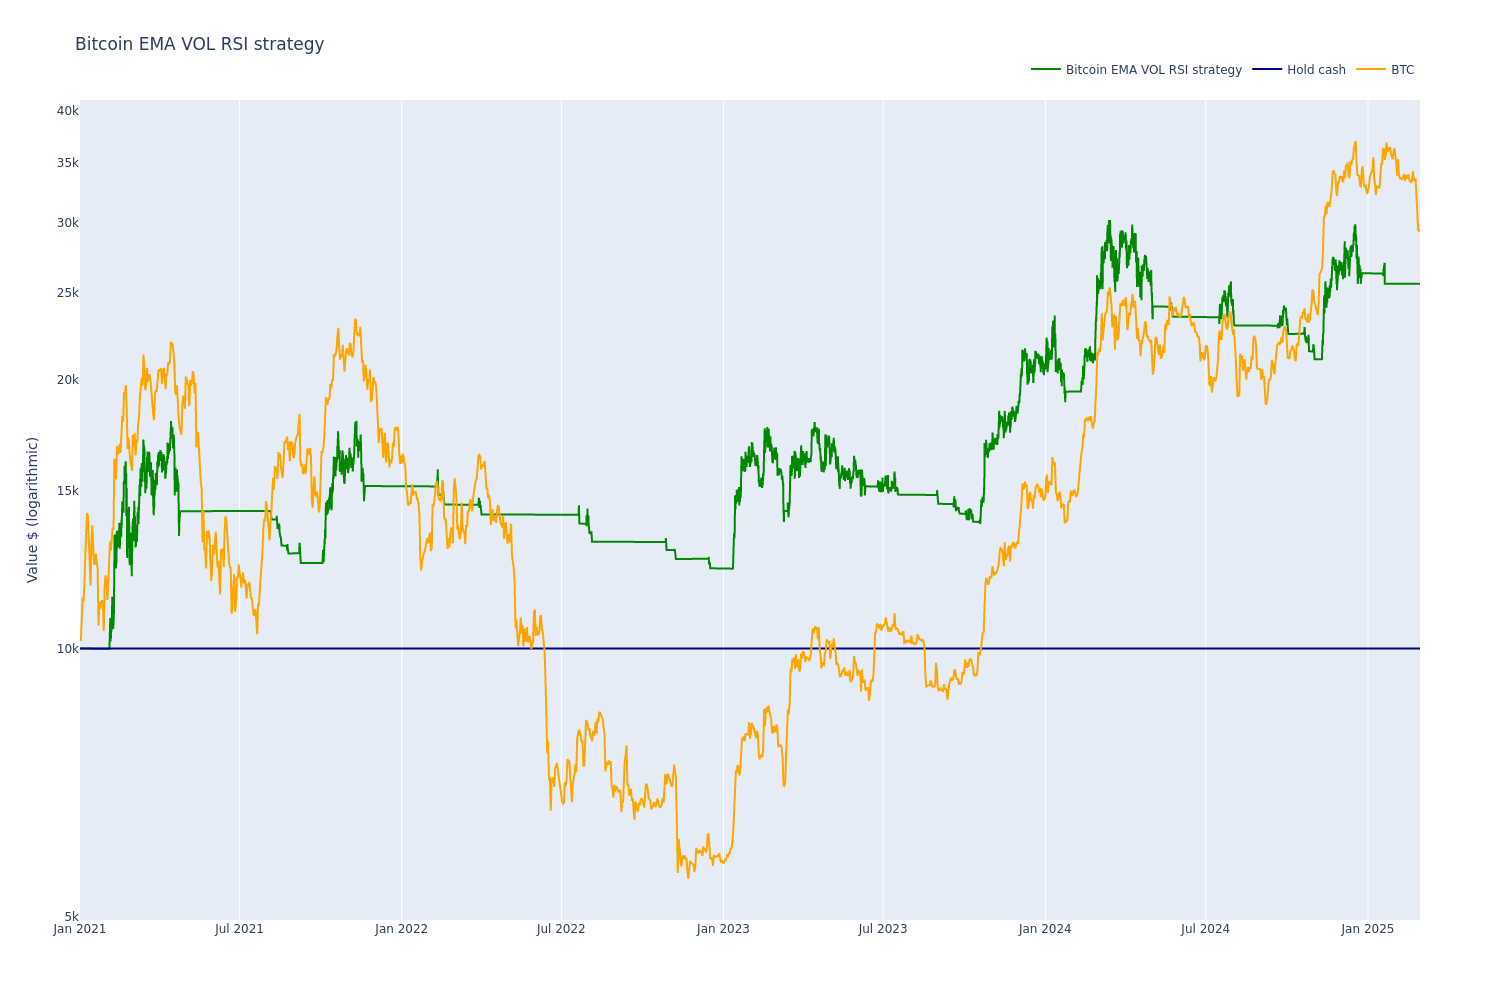

In [9]:
import pandas as pd
from tradeexecutor.analysis.multi_asset_benchmark import get_benchmark_data
from tradeexecutor.visual.benchmark import visualise_equity_curve_benchmark

benchmark_indexes = get_benchmark_data(
    strategy_universe,
    cumulative_with_initial_cash=state.portfolio.get_initial_cash()
)

fig = visualise_equity_curve_benchmark(
    name="Bitcoin EMA VOL RSI strategy",
    state=state,
    all_cash=state.portfolio.get_initial_cash(),
    benchmark_indexes=benchmark_indexes,
    height=800,
    log_y=True,
)

fig.show()

# Technical indicator and trade visualisation

- Draw the technical indicators we filled in in `decide_trades()`
- Show the made trades on the price chart for a single trading pair
- You need to zoom in to see the bollinger bands, as the default chart width is full multi-year study.
  However the default notebook chart mode is static images, as interactive images are a bit slow on Github Codespaces.

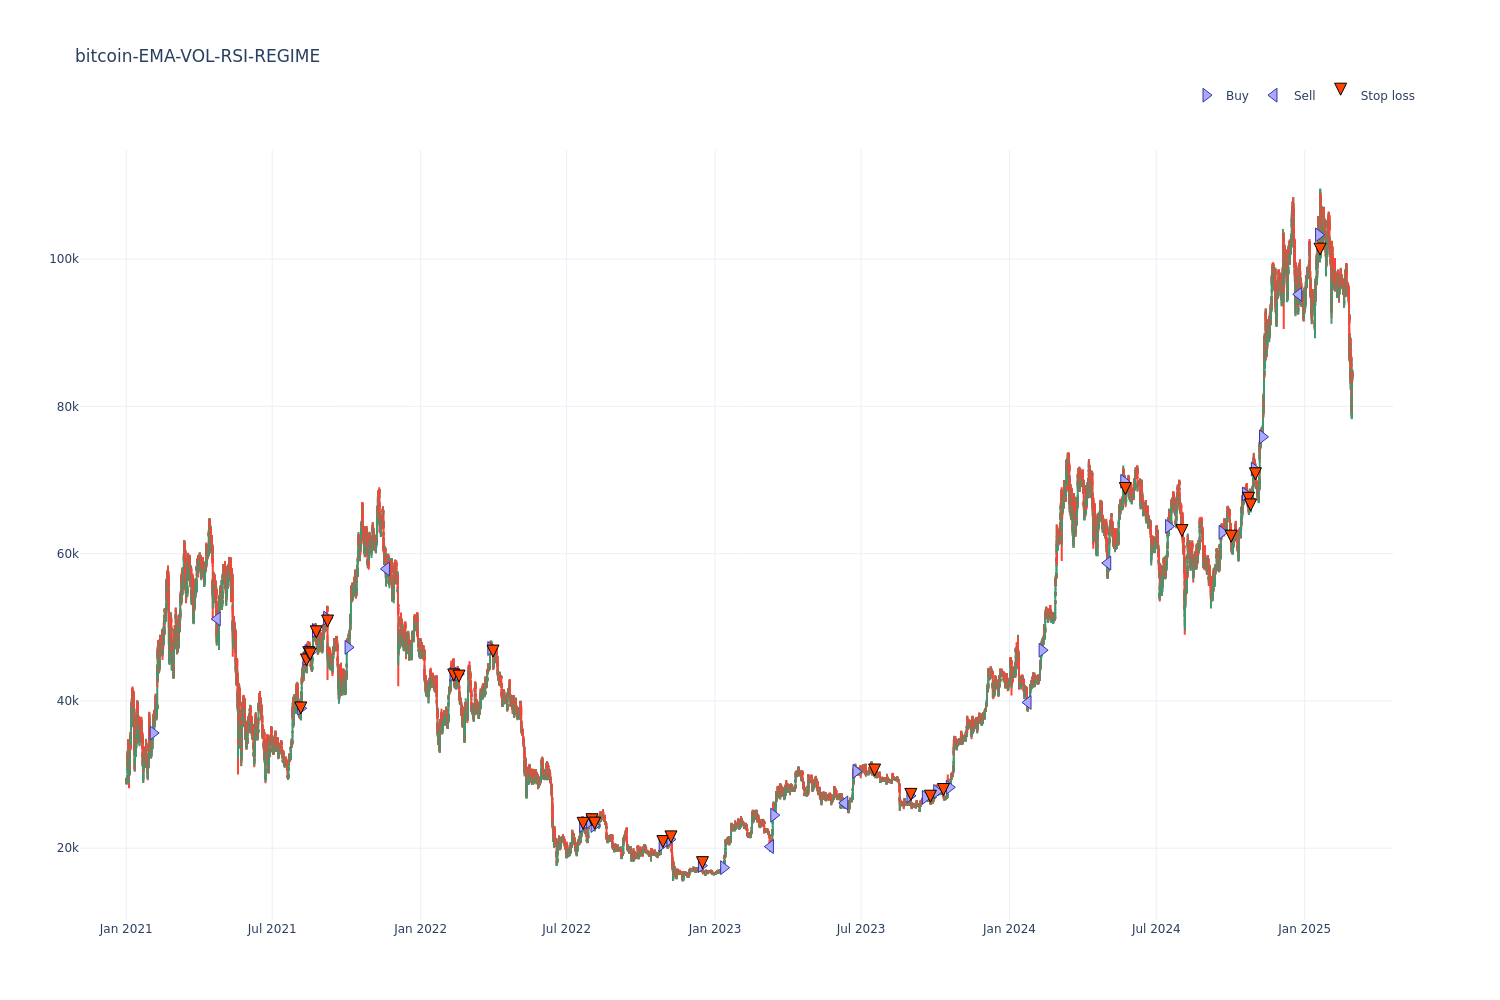

In [10]:
from tradeexecutor.visual.single_pair import visualise_single_pair
from tradingstrategy.charting.candle_chart import VolumeBarMode

start_at, end_at = state.get_strategy_start_and_end()   # Limit chart to our backtesting range

figure = visualise_single_pair(
    state,
    execution_context=notebook_execution_context,
    candle_universe=strategy_universe.data_universe.candles,
    start_at=start_at,
    end_at=end_at,
    volume_bar_mode=VolumeBarMode.hidden,
    volume_axis_name="Volume (USD)",
    height = 1000,
)

figure.show()

# Regime filter visualisation 

- Visualise the regime filter to show how well our bear/bull market flagging works

In [11]:
# Pull the pair and its close price we are detecting regimes for
indicators = result.indicators
daily_price = indicators.get_indicator_dataframe("daily_price", pair=trading_pairs[0])
close_price = daily_price["close"]

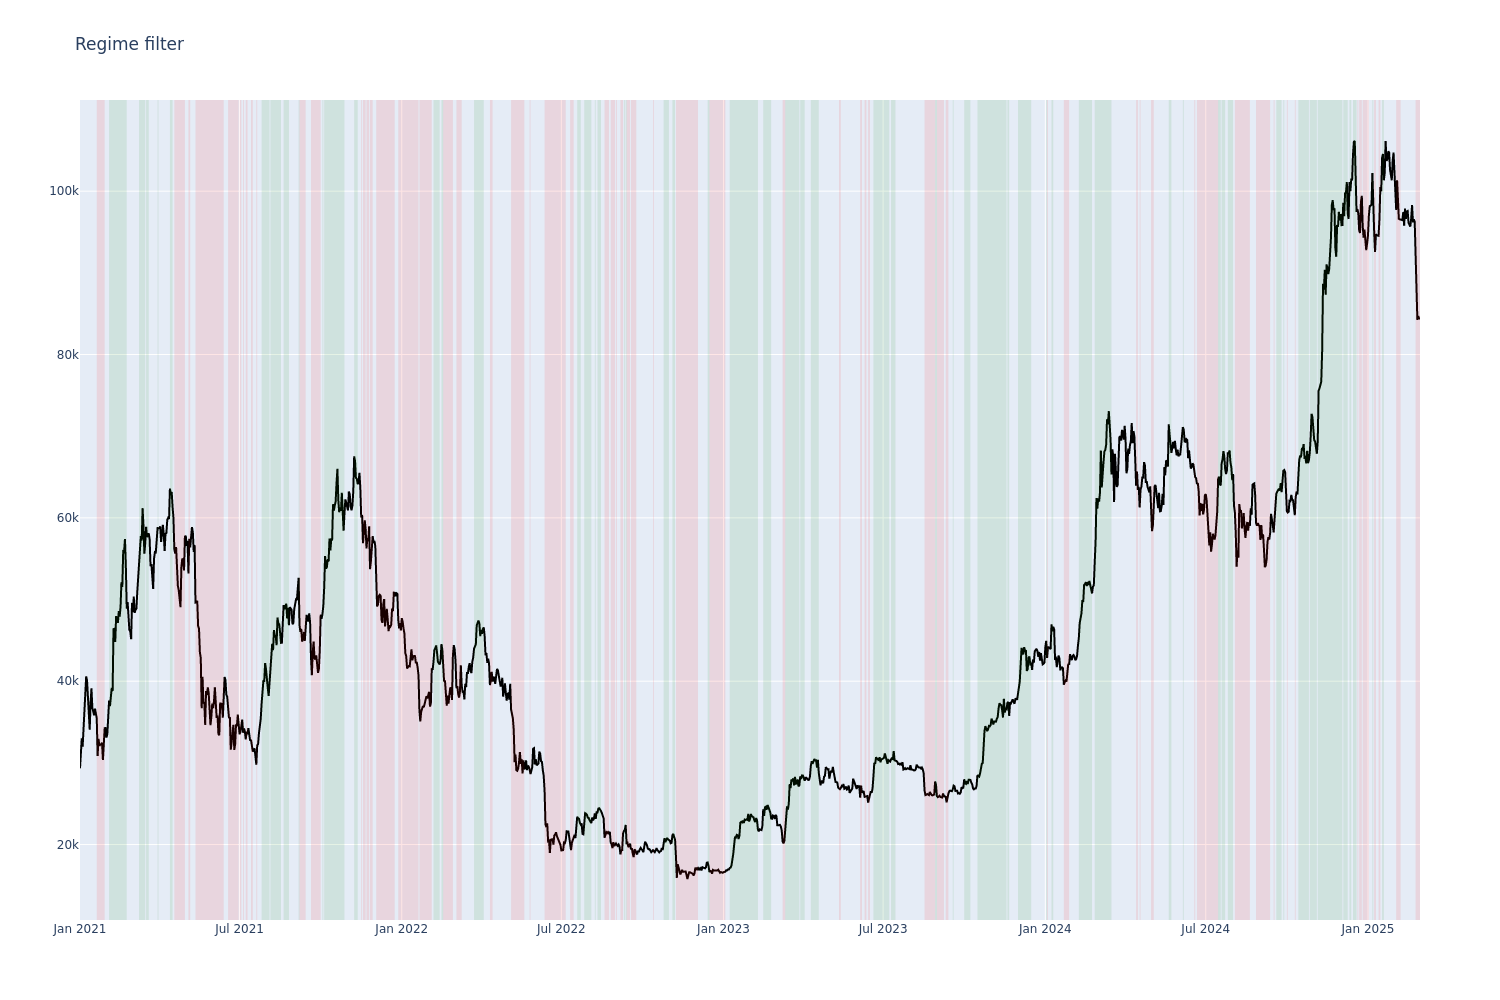

In [12]:
from tradeexecutor.visual.bullbear import visualise_market_regime_filter

regime_signal = result.indicators.get_indicator_series("regime", pair=trading_pairs[0], unlimited=True)
visualise_market_regime_filter(
    close_price,
    regime_signal,
)

# Performance metrics

- Display portfolio performance metrics
- Compare against buy and hold matic using the same initial capital

In [13]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

compare_strategy_backtest_to_multiple_assets(
    state,
    strategy_universe,
    display=True,
)

,Strategy,BTC
Start Period,2021-01-01,2021-01-01
End Period,2025-02-28,2025-02-28
Risk-Free Rate,0.0%,0.0%
Time in Market,41.0%,98.0%
Cumulative Return,156.12%,149.58%
CAGR﹪,16.89%,16.39%
Sharpe,0.83,0.67
Prob. Sharpe Ratio,95.98%,91.37%
Smart Sharpe,0.8,0.64
Sortino,1.36,0.98


# Trading statistics

- Display summare about made trades

In [14]:
from tradeexecutor.analysis.trade_analyser import build_trade_analysis

analysis = build_trade_analysis(state.portfolio)
summary = analysis.calculate_summary_statistics()
display(summary.to_dataframe())

,0
Trading period length,1446 days 14 hours
Trading start,None
Trading end,None
Return %,156.12%
Annualised return %,39.39%
Cash at start,"$10,000.00"
Value at end,"$25,611.54"
Time in market,0.00%
Time in market volatile,0.00%
Trade volume,"$1,056,138.61"


# Rolling Sharpe

- See how the six months rolling Sharpe ratio changes over time

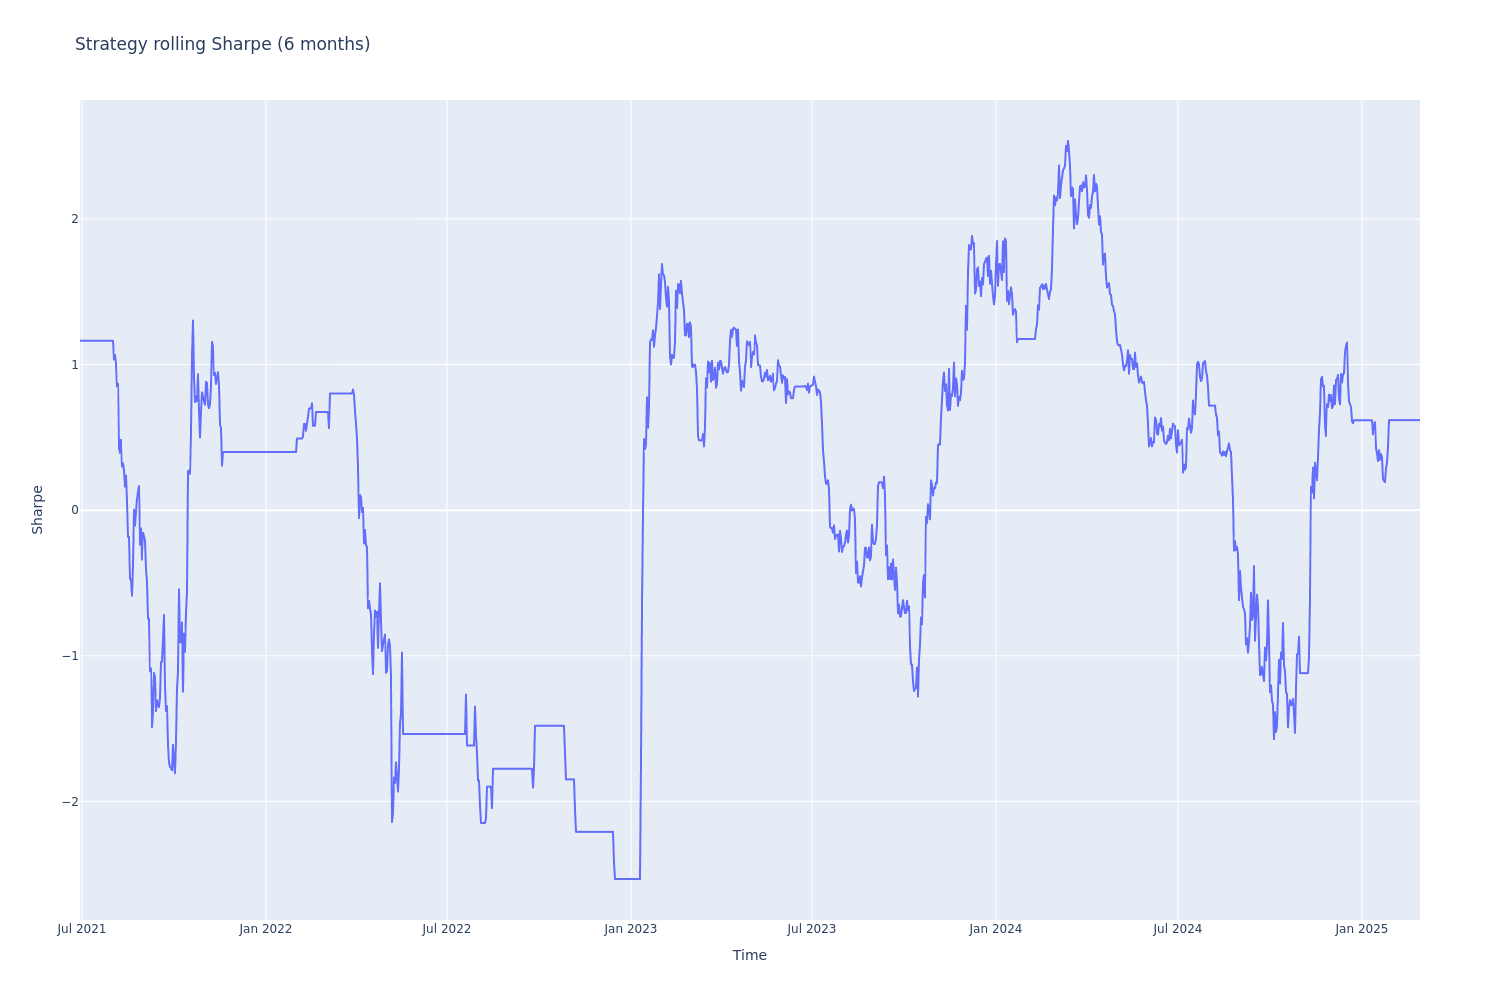

In [15]:
import plotly.express as px

from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.visual.equity_curve import calculate_rolling_sharpe

equity = calculate_equity_curve(state)
returns = calculate_returns(equity)

rolling_sharpe = calculate_rolling_sharpe(
    returns,
    freq="D",
    periods=180,
)

fig = px.line(rolling_sharpe, title='Strategy rolling Sharpe (6 months)')
fig.update_layout(showlegend=False)
fig.update_yaxes(title="Sharpe")
fig.update_xaxes(title="Time")
fig.show()